In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scanpy as sc
import numpy as np
import pandas as pd
import os
from sklearn.metrics.pairwise import euclidean_distances
from sklearn import svm
from sklearn.preprocessing import MinMaxScaler
import pickle
import mygene
import anndata
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import random
from glob import glob
from tqdm import tqdm
import torch

# Cell-type-wise calculation for handling memory overflow

In [2]:
def get_adata_left_right_pi(data1, data2):
    adata_left = sc.read(f'./data/Mouse_brain_MERFISH_imputed/{data1}.h5ad')
    adata_right = sc.read(f'./data/Mouse_brain_MERFISH_imputed/{data2}.h5ad')
    pi = np.load(f'./local_data/incent/pi_matrix_{data1}_{data2}.npy')
    return adata_left, adata_right, pi

def get_gexp_pi_index_for_cell_type(adata_left, adata_right, pi, cell_type_left, cell_type_right='all'):
    '''
    cell_type_left = 'all' for taking all cell types for the adata_left sample
    cell_type_right = 'all' for taking all cell types for the adata_right sample
    '''
    
    df_obs_left = adata_left.obs
    df_obs_left['idx'] = np.arange(df_obs_left.shape[0])
    if cell_type_left != 'all':
        left_idxs = df_obs_left[df_obs_left['cell_type_annot'] == cell_type_left]['idx'].values
    else:
        left_idxs = df_obs_left['idx'].values

    df_obs_right = adata_right.obs
    df_obs_right['idx'] = np.arange(df_obs_right.shape[0])
    if cell_type_right != 'all':
        right_idxs = df_obs_right[df_obs_right['cell_type_annot'] == cell_type_right]['idx'].values
    else:
        right_idxs = df_obs_right['idx'].values

    if 'sparse' in str(type(adata_left.X)):
        return adata_left.X.toarray()[left_idxs], adata_right.X.toarray()[right_idxs], pi[left_idxs][:, right_idxs], left_idxs
    else:
        return adata_left.X[left_idxs], adata_right.X[right_idxs], pi[left_idxs][:, right_idxs], left_idxs

def get_c_ij(gexp_left, gexp_right):
    c_i = np.sqrt(1 + np.sum(gexp_left ** 2, axis=1))
    c_j = np.sqrt(1 + np.sum(gexp_right ** 2, axis=1))

    c_ij = c_i[:, None] * c_j[None, :]
    return c_ij

In [3]:
df_age_group_4_24 = pd.read_csv(f'./local_data/age-prog-score/score_4_24_imputed.csv', index_col=0)
df_age_group_24_90 = pd.read_csv(f'./local_data/age-prog-score/score_24_90_imputed.csv', index_col=0)
all_4_24 = df_age_group_4_24.groupby('self_sample')['reference_sample'].describe().reset_index()[['self_sample', 'top']].values
all_24_90 = df_age_group_24_90.groupby('self_sample')['reference_sample'].describe().reset_index()[['self_sample', 'top']].values

all_4_24 = np.array([sample_pair for sample_pair in all_4_24 if '24' in sample_pair[0]])
all_24_90 = np.array([sample_pair for sample_pair in all_24_90 if '90' in sample_pair[0]])

In [ ]:
for data in tqdm(np.vstack((all_4_24, all_24_90))):
    data1 = data[1]
    data2 = data[0]
    
    print(data1, data2)
    
    adata_left, adata_right, pi = get_adata_left_right_pi(data1, data2)
    
    # print(adata_left.n_obs, adata_left.n_vars)
    # print(str(type(adata_left.X)))
    
    left_age = data1.split('adata')[-1].split('_')[0]
    left_donor_id = data1.split('donor_id_')[-1].split('_')[0]
    left_slice = int(data1.split('_')[-1])

    right_age = data2.split('adata')[-1].split('_')[0]
    right_donor_id = data2.split('donor_id_')[-1].split('_')[0]
    right_slice = int(data2.split('_')[-1])
    
    print(left_age, left_donor_id, left_slice)
    print(right_age, right_donor_id, right_slice)
    
    if left_age == '4wk':
        df_age_group = df_age_group_4_24
    else:
        df_age_group = df_age_group_24_90

    cell_types = adata_left.obs['cell_type_annot'].unique().tolist()

    df_imp_genes_all = pd.DataFrame(index=np.arange(adata_left.n_obs), columns=['age', 'donor_id', 'slice', 'cell_type', 'gene'])

    for cell_type_left in cell_types:
        print(cell_type_left)
        mat_gene_imp_overall = None
        # c = 0
        for cell_type_right in cell_types:
            gexp_left, gexp_right, pi_ct, left_idxs = get_gexp_pi_index_for_cell_type(adata_left, adata_right, pi, cell_type_left=cell_type_left, cell_type_right=cell_type_right)
            
            c_ij = get_c_ij(gexp_left, gexp_right)
            pi_by_c_ij = pi_ct / c_ij
            mat_gene_imp = pi_by_c_ij[:, :, None] * (gexp_left[:, None] * gexp_right[None, :])
            mat_gene_imp_sum = mat_gene_imp.sum(axis=1)
            if mat_gene_imp_overall is None:
                mat_gene_imp_overall = mat_gene_imp_sum
            else:
                mat_gene_imp_overall += mat_gene_imp_sum
            
            # c+=1
            # if c < 2:
            #     print('HERE:', mat_gene_imp_overall.shape)
            # else:
            #     break
            
        # break

        score_pred = (1/adata_left.n_obs - mat_gene_imp_overall.sum(axis=1) - pi_by_c_ij.sum(axis=1)) * adata_left.n_obs * 100
        # df_specific = df_age_group[(df_age_group['donor_id'] == f'MsBrainAgingSpatialDonor_{left_donor_id}') & (df_age_group['age'] == left_age) & (df_age_group['slice'] == left_slice) & (df_age_group['cell_type_annot'] == cell_type_left)]
        df_specific = df_age_group[(df_age_group['self_sample'] == data1) & (df_age_group['reference_sample'] == data2) & (df_age_group['cell_type_annot'] == cell_type_left)]
        age_prog_score = df_specific['age_progression_score'].values
        print((100 * abs(age_prog_score - score_pred)/age_prog_score).max())
        
        imp_gene_idxs = np.argmin(mat_gene_imp_overall, axis=1)
        imp_genes_per_cell = adata_left.var['feature_name'].values[imp_gene_idxs]

        df_imp_genes_all.loc[left_idxs.tolist(), 'gene'] = imp_genes_per_cell.tolist()
        df_imp_genes_all.loc[left_idxs.tolist(), 'cell_type'] = cell_type_left
        df_imp_genes_all.loc[left_idxs.tolist(), 'age'] = left_age
        df_imp_genes_all.loc[left_idxs.tolist(), 'donor_id'] = f'MsBrainAgingSpatialDonor_{left_donor_id}'
        df_imp_genes_all.loc[left_idxs.tolist(), 'slice'] = left_slice

        map_gene_count = {}
        for gene in imp_genes_per_cell:
            gene_name = gene.split('_')[0]
            map_gene_count[gene_name] = map_gene_count.get(gene_name, 0) + 1
        # map_gene_count
        df_gene_count = pd.DataFrame({'gene': map_gene_count.keys(), 'count': map_gene_count.values()})
        # print(df_gene_count.sort_values('count', ascending=False))
        
        break
    df_imp_genes_all.groupby('cell_type')['gene'].describe().reset_index().to_csv(f'./local_data/important_genes/{data1}_vs_{data2}_imp_genes_description.csv')

  0%|          | 0/13 [00:00<?, ?it/s]

adata4wk_donor_id_8_slice_0 adata24wk_donor_id_10_slice_0
4wk 8 0
24wk 10 0
OPC
HERE: (502, 7308)


In [14]:
file_name_list_4_24 = glob('./local_data/important_genes/*4wk*24wk*')
file_name_list_24_90 = glob('./local_data/important_genes/*24wk*90wk*')

df_4_24_combined = pd.concat([pd.read_csv(file_name) for file_name in file_name_list_4_24], ignore_index=True)
df_24_90_combined = pd.concat([pd.read_csv(file_name) for file_name in file_name_list_24_90], ignore_index=True)
df_24_90_combined

,Unnamed: 0,cell_type,count,unique,top,freq
0,0,Astro,709,211,Hipk2_ENSMUSG00000061436,35
1,1,Endo,258,123,Nfkbia_ENSMUSG00000021025,31
2,2,Epen,5,5,Trio_ENSMUSG00000022263,1
3,3,ExN,2386,275,Cd47_ENSMUSG00000055447,149
4,4,InN,661,206,Cd47_ENSMUSG00000055447,32
...,...,...,...,...,...,...
60,8,OPC,206,83,Cspg4_ENSMUSG00000032911,13
61,9,Olig,1305,166,Hipk2_ENSMUSG00000061436,349
62,10,Peri,217,74,Sparc_ENSMUSG00000018593,30
63,11,T cell,5,5,B2m_ENSMUSG00000060802,1


In [6]:
# Group by gene name ('top') and sum frequencies
gene_freq_4_24 = df_4_24_combined.groupby('top')['freq'].sum().reset_index()
gene_freq_24_90 = df_24_90_combined.groupby('top')['freq'].sum().reset_index()

gene_freq_4_24['gene'] = [gene.split('_')[0] for gene in gene_freq_4_24['top'].values]
gene_freq_24_90['gene'] = [gene.split('_')[0] for gene in gene_freq_24_90['top'].values]

gene_freq_4_24 = gene_freq_4_24[['gene', 'freq']].sort_values('freq', ascending=False)
gene_freq_24_90 = gene_freq_24_90[['gene', 'freq']].sort_values('freq', ascending=False)

In [7]:
s1 = set(gene_freq_4_24['gene'].values)
s2 = set(gene_freq_24_90['gene'].values)

s1.intersection(s2)

{'Aldoc',
 'C1ql1',
 'Cd47',
 'Cd74',
 'Hexb',
 'Mrc1',
 'Myh11',
 'Ncor2',
 'Rsrp1',
 'Sparc',
 'Sptan1',
 'Srebf2',
 'Tcf25',
 'Trio'}

In [11]:
gene_freq_4_24

,gene,freq
26,Rsrp1,2432
22,Ncor2,810
3,Bnc2,584
15,Fth1,460
7,Cd47,213
31,Syt6,205
28,Sparc,197
9,Cnr1,183
24,Plekhg1,168
17,Hexb,167


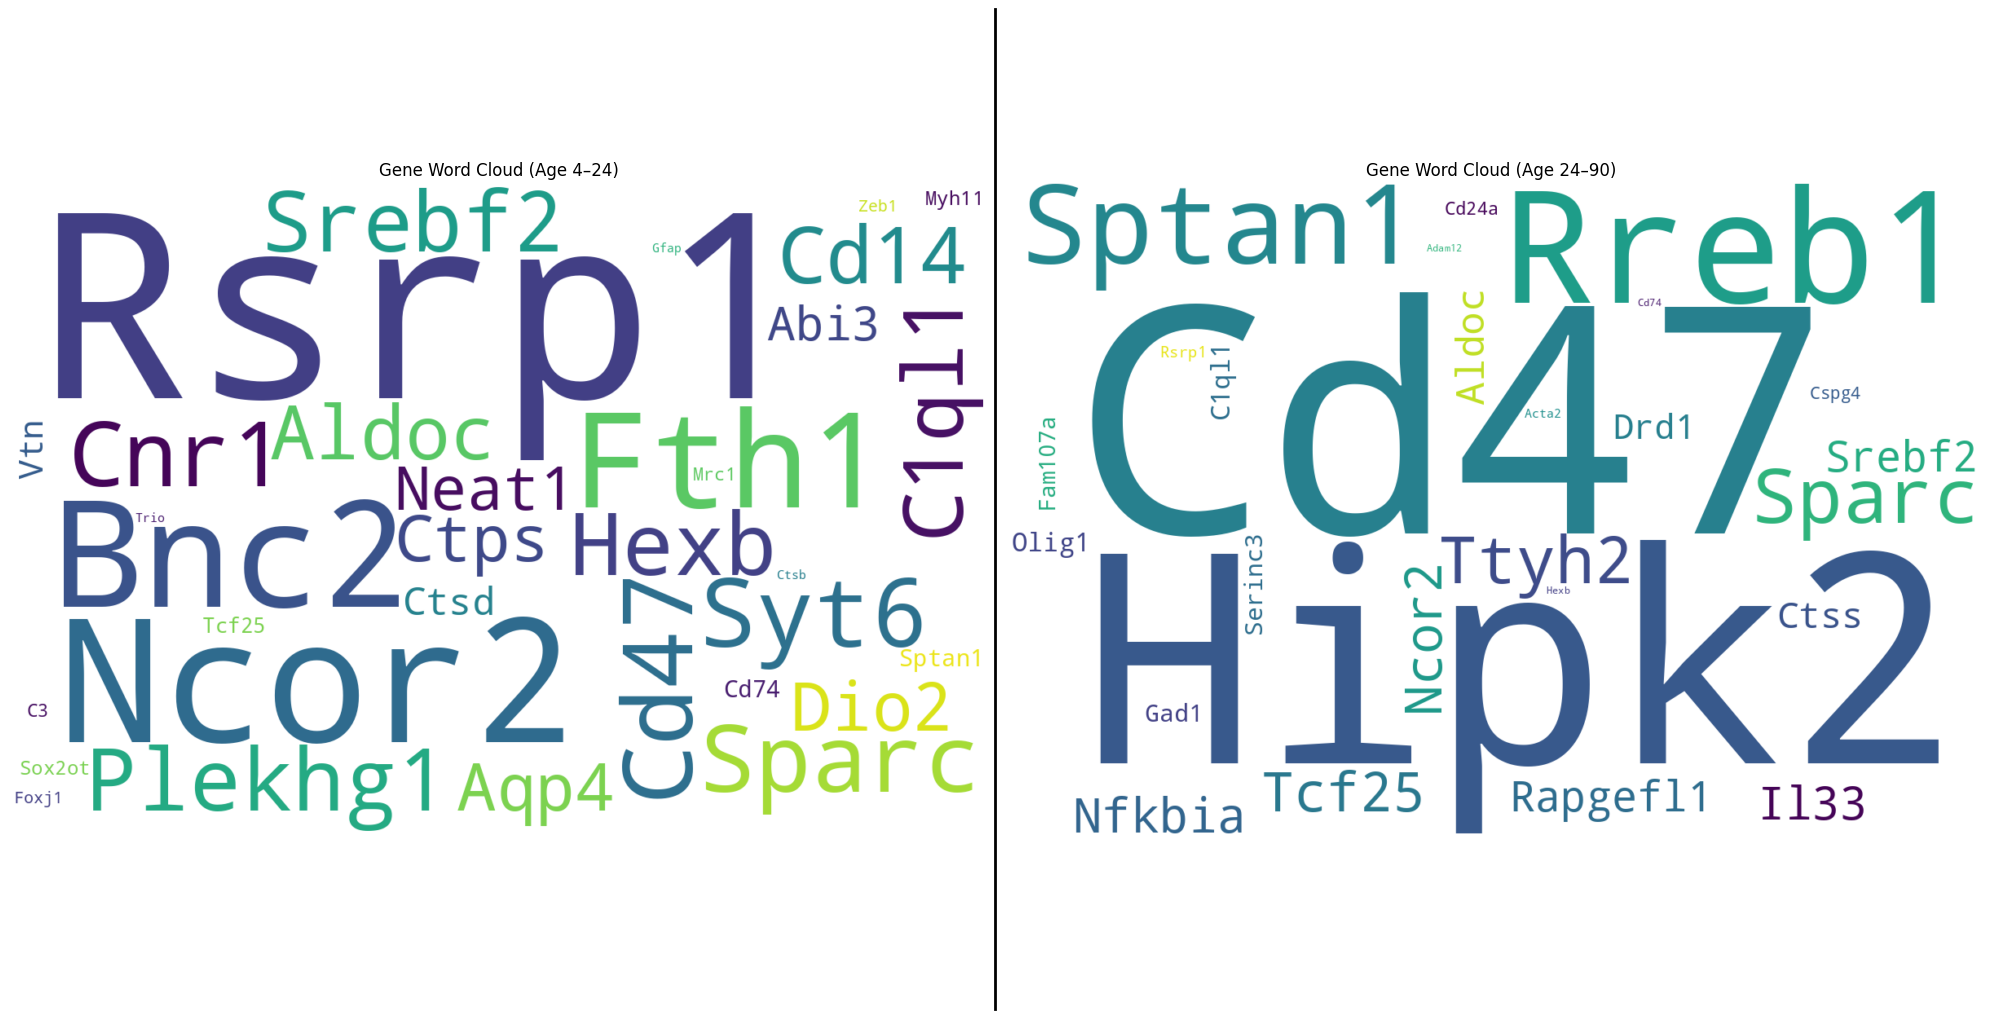

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert to dictionary: {gene_name: total_frequency}
freq_dict_4_24 = dict(zip(gene_freq_4_24['gene'], gene_freq_4_24['freq']))
freq_dict_24_90 = dict(zip(gene_freq_24_90['gene'], gene_freq_24_90['freq']))

# Word cloud for 4–24 age group
wc_4_24 = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    prefer_horizontal=0.9,
    min_font_size=12  # 👈 ensure smallest words are still visible
).generate_from_frequencies(freq_dict_4_24)

# Word cloud for 24–90 age group
wc_24_90 = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    prefer_horizontal=0.9,
    min_font_size=12
).generate_from_frequencies(freq_dict_24_90)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(wc_4_24, interpolation="bilinear")
axes[0].set_title("Gene Word Cloud (Age 4–24)")
axes[0].axis("off")

axes[1].imshow(wc_24_90, interpolation="bilinear")
axes[1].set_title("Gene Word Cloud (Age 24–90)")
axes[1].axis("off")

# Adjust space between plots
fig.subplots_adjust(wspace=0.05)

# Add vertical border line in the middle
fig.canvas.draw()
fig_width = fig.get_size_inches()[0]
divider_x = 0.5  # normalized figure coordinates
fig.lines.append(plt.Line2D([divider_x, divider_x], [0, 1], transform=fig.transFigure, color="black", lw=2))

plt.tight_layout()
plt.show()


In [13]:
freq_dict_24_90


{'Cd47': 1138,
 'Hipk2': 971,
 'Rreb1': 377,
 'Sptan1': 374,
 'Sparc': 332,
 'Ttyh2': 238,
 'Tcf25': 160,
 'Ncor2': 140,
 'Nfkbia': 122,
 'Il33': 109,
 'Rapgefl1': 94,
 'Srebf2': 93,
 'Aldoc': 80,
 'Ctss': 67,
 'Drd1': 61,
 'Olig1': 32,
 'C1ql1': 31,
 'Gad1': 27,
 'Serinc3': 27,
 'Fam107a': 24,
 'Cd24a': 14,
 'Cspg4': 13,
 'Rsrp1': 10,
 'Acta2': 6,
 'Adam12': 4,
 'Hexb': 4,
 'Cd74': 4,
 'Lyz2': 3,
 'Mrc1': 3,
 'Myh11': 1,
 'Tap1': 1,
 'Bbx': 1,
 'Trio': 1,
 'B2m': 1,
 'Zbtb20': 1}

In [18]:
for gene in list(freq_dict_4_24.keys())[:20]:
    print(gene)

Rsrp1
Ncor2
Bnc2
Fth1
Cd47
Syt6
Sparc
Cnr1
Plekhg1
Hexb
Srebf2
C1ql1
Cd14
Aldoc
Dio2
Aqp4
Ctps
Neat1
Abi3
Ctsd


In [19]:
for gene in list(freq_dict_24_90.keys())[:20]:
    print(gene)

Cd47
Hipk2
Rreb1
Sptan1
Sparc
Ttyh2
Tcf25
Ncor2
Nfkbia
Il33
Rapgefl1
Srebf2
Aldoc
Ctss
Drd1
Olig1
C1ql1
Gad1
Serinc3
Fam107a


In [24]:
df_merged = pd.DataFrame()
imp_genes_file_paths = glob('./local_data/important_genes/adata*')
for file_path in imp_genes_file_paths:
    df = pd.read_csv(file_path, index_col=0)
    # print(df['cell_type'])
    df_merged = pd.concat([df_merged, df])
    
df_merged

,cell_type,count,unique,top,freq
0,Astro,1173,217,Rsrp1_ENSMUSG00000037266,74
1,Endo,1026,219,Rsrp1_ENSMUSG00000037266,51
2,Epen,36,27,Foxj1_ENSMUSG00000034227,4
3,ExN,2383,259,Ncor2_ENSMUSG00000029478,169
4,InN,1106,238,Ncor2_ENSMUSG00000029478,59
...,...,...,...,...,...
8,OPC,206,83,Cspg4_ENSMUSG00000032911,13
9,Olig,1305,166,Hipk2_ENSMUSG00000061436,349
10,Peri,217,74,Sparc_ENSMUSG00000018593,30
11,T cell,5,5,B2m_ENSMUSG00000060802,1


In [25]:
df_merged = df_merged.rename(columns={'top': 'gene', 'count': 'cell_count', 'unique': 'unique_genes'})
df_merged = df_merged.groupby(['cell_type', 'gene'])[['freq']].sum().reset_index().sort_values(by=['cell_type', 'freq'], ascending=False)
df_merged

,cell_type,gene,freq
91,Vlmc,Ncor2_ENSMUSG00000029478,24
93,Vlmc,Sparc_ENSMUSG00000018593,21
92,Vlmc,Rsrp1_ENSMUSG00000037266,9
94,Vlmc,Tcf25_ENSMUSG00000001472,7
88,Vlmc,Acta2_ENSMUSG00000035783,6
...,...,...,...
1,Astro,Aqp4_ENSMUSG00000024411,99
6,Astro,Srebf2_ENSMUSG00000022463,91
7,Astro,Tcf25_ENSMUSG00000001472,50
4,Astro,Hipk2_ENSMUSG00000061436,35


In [27]:
for cell_type in df_merged['cell_type'].unique():
    df_merged[df_merged['cell_type'] == cell_type].to_csv(f'./local_data/important_genes/{cell_type}_imp_genes.csv')
    

In [ ]:
df_imp_genes_all.groupby('cell_type')['gene'].describe().reset_index()

In [ ]:
df_imp_genes_all.groupby('cell_type').describe().reset_index()

In [ ]:
len(imp_genes_per_cell.tolist())

In [ ]:
adata_left.var['feature_name'].values[322]

In [ ]:
t1 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
t2 = np.array([[3, 2, 1], [6, 5, 4]])

get_c_ij(t1, t2)


In [ ]:
g_ijk = gexp_left[:, None, :] * gexp_right[None, :, :] * pi_ct[:, :, None]

In [ ]:
g_ijk[0]

In [ ]:
test_left = np.array([[1, -2, 3],
                      [4, 5, 6],
                      [7, -8, 9],
                      [3, 4, 5]])

test_right = np.array([[10, -20, -30],
                       [40, 50, 60]])

pi_test = np.array([[0.1, 0],
                    [0.2, 0.3],
                    [0, 0.1],
                    [0.3, 0]])

In [ ]:
# prev = np.ones((test_left.shape[0], test_right.shape[0])) + 10000000
# mindex = np.ones((test_left.shape[0], test_right.shape[0]), dtype='int') + 10000000
# for k in tqdm(range(test_left.shape[1])):
#     g_ijk = test_left[:, None, k] * test_right[None, :, k]
#     print('g_ijk', g_ijk)
#     pi_gijk = pi_test * g_ijk
#     print('pi_gijk', pi_gijk)
#     idxs = np.where(prev > pi_gijk)
#     print('idxs', idxs)
#     mindex[idxs[0], idxs[1]] = k
#     print('mindex', mindex)
#     print('prev', prev)
#     prev[idxs[0], idxs[1]] = pi_gijk[idxs[0], idxs[1]]
#     print('prev', prev)
#     print()
#     # break
# mindex

In [ ]:
prev = np.ones((adata_left.n_obs, adata_right.n_obs)) + 10000000
mindex = np.ones((adata_left.n_obs, adata_right.n_obs), dtype='int') + 10000000
gexp_left = adata_left.X
gexp_right = adata_right.X

# prev = torch.from_numpy(prev)
# mindex = torch.from_numpy(mindex)
# pi = torch.from_numpy(pi)
# gexp_left = torch.from_numpy(adata_left.X)
# gexp_right = torch.from_numpy(adata_right.X)

# if torch.cuda.is_available():
#     prev = prev.cuda()
#     mindex = mindex.cuda()
#     pi = pi.cuda()
#     gexp_left = gexp_left.cuda()
#     gexp_right = gexp_right.cuda()
# else:
#     print('cuda unavailable.')

for k in tqdm(range(adata_left.n_vars)):
    g_ijk = gexp_left[:, None, k] * gexp_right[None, :, k]
    pi_gijk = pi * g_ijk
    idxs = np.where(prev > pi_gijk)
    mindex[idxs[0], idxs[1]] = k
    prev[idxs[0], idxs[1]] = pi_gijk[idxs[0], idxs[1]]

mindex

In [ ]:
idxs = np.where(mindex[0] > 0)[0]
print(idxs)
adata_left.var_names[mindex[0][idxs]]

In [ ]:
adata_left.var['feature_name']